<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/faster_rcnn_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
url = "https://thumbs.dreamstime.com/b/cute-cat-sleeping-street-car-random-58655731.jpg"

In [4]:
import requests
from io import BytesIO

200


(np.float64(-0.5), np.float64(799.5), np.float64(568.5), np.float64(-0.5))

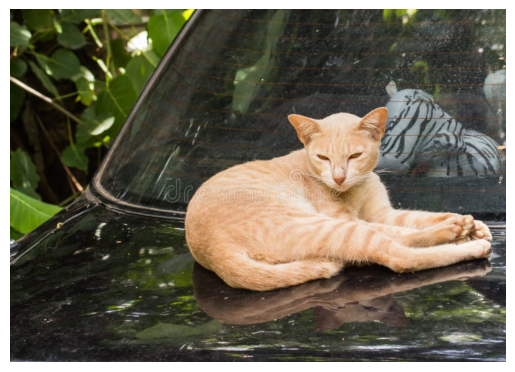

In [5]:
response = requests.get(url)

print(response.status_code)  # should be 200

img = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(img)
plt.axis("off")

In [6]:
transform = transforms.Compose([
    transforms.Resize(600),
    transforms.ToTensor()
])

image_tensor = transform(img).unsqueeze(0).to(device)

print(image_tensor.shape)

torch.Size([1, 3, 600, 843])


### Backbone Network

In [7]:
backbone = torchvision.models.resnet50(weights="IMAGENET1K_V1")

modules = list(backbone.children())[:-2]
backbone = nn.Sequential(*modules)

backbone = backbone.to(device)
backbone.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 58.8MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [8]:
with torch.no_grad():
    feature_map = backbone(image_tensor)

print(feature_map.shape)

torch.Size([1, 2048, 19, 27])


### Anchors

In [9]:
anchor_scales = [128, 256, 512]
aspect_ratios = [0.5, 1, 2]

In [10]:
def generate_base_anchors(scales, ratios):

    anchors = []

    for scale in scales:
        for ratio in ratios:

            w = scale * np.sqrt(1/ratio)
            h = scale * np.sqrt(ratio)

            anchors.append([0,0,w,h])

    return np.array(anchors)

In [11]:
base_anchors = generate_base_anchors(anchor_scales, aspect_ratios)

print(base_anchors)

[[  0.           0.         181.01933598  90.50966799]
 [  0.           0.         128.         128.        ]
 [  0.           0.          90.50966799 181.01933598]
 [  0.           0.         362.03867197 181.01933598]
 [  0.           0.         256.         256.        ]
 [  0.           0.         181.01933598 362.03867197]
 [  0.           0.         724.07734394 362.03867197]
 [  0.           0.         512.         512.        ]
 [  0.           0.         362.03867197 724.07734394]]


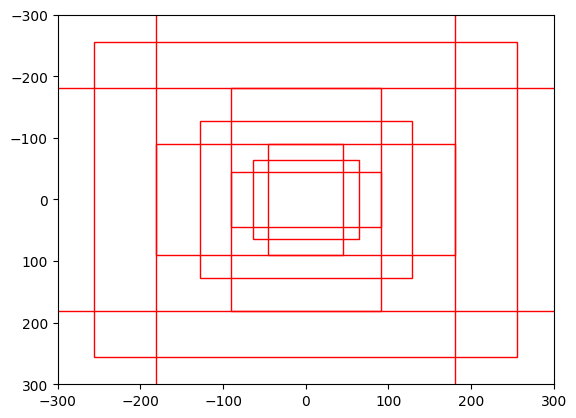

In [12]:
fig, ax = plt.subplots()

for anchor in base_anchors:

    w = anchor[2]
    h = anchor[3]

    rect = plt.Rectangle((-w/2, -h/2), w, h,
                         fill=False,
                         edgecolor='red')

    ax.add_patch(rect)

ax.set_xlim(-300,300)
ax.set_ylim(-300,300)

plt.gca().invert_yaxis()
plt.show()

In [13]:
_,_,H,W = feature_map.shape
print(H,W)

19 27


In [14]:
def generate_anchors(feature_map_size, stride, base_anchors):

    H, W = feature_map_size

    all_anchors = []

    for y in range(H):
        for x in range(W):

            center_x = x * stride
            center_y = y * stride

            for anchor in base_anchors:

                w = anchor[2]
                h = anchor[3]

                all_anchors.append([
                    center_x,
                    center_y,
                    w,
                    h
                ])

    return np.array(all_anchors)

In [15]:
anchors = generate_anchors(
    (H,W),
    stride=16,
    base_anchors=base_anchors
)

print("Total anchors:", anchors.shape)

Total anchors: (4617, 4)


In [16]:
def anchors_to_boxes(anchors):

    boxes = []

    for a in anchors:

        cx,cy,w,h = a

        x1 = cx - w/2
        y1 = cy - h/2
        x2 = cx + w/2
        y2 = cy + h/2

        boxes.append([x1,y1,x2,y2])

    return np.array(boxes)

In [17]:
anchor_boxes = anchors_to_boxes(anchors)

print(anchor_boxes[:5])

[[ -90.50966799  -45.254834     90.50966799   45.254834  ]
 [ -64.          -64.           64.           64.        ]
 [ -45.254834    -90.50966799   45.254834     90.50966799]
 [-181.01933598  -90.50966799  181.01933598   90.50966799]
 [-128.         -128.          128.          128.        ]]


In [18]:
feature_map.shape
anchors.shape

(4617, 4)

In [19]:
print("Feature map shape:", feature_map.shape)
print("H, W:", H, W)
print("Total anchors:", anchors.shape)

Feature map shape: torch.Size([1, 2048, 19, 27])
H, W: 19 27
Total anchors: (4617, 4)


## Region Proposal Network

In [20]:
class RPN(nn.Module):
    def __init__(self, in_channels, num_anchors):
        super().__init__()

        self.conv = nn.Conv2d(in_channels, 512, kernel_size=3, padding=1)

        # objectness score
        self.cls_head = nn.Conv2d(512, num_anchors * 2, kernel_size=1)

        # bbox regression
        self.reg_head = nn.Conv2d(512, num_anchors * 4, kernel_size=1)

    def forward(self, x):

        x = F.relu(self.conv(x))

        cls_logits = self.cls_head(x)
        bbox_reg = self.reg_head(x)

        return cls_logits, bbox_reg

In [21]:
num_anchors = 9
rpn = RPN(in_channels=2048, num_anchors=num_anchors).to(device)

In [74]:
cls_logits_rpn, bbox_reg_rpn = rpn(feature_map)

print("cls_logits:", cls_logits_rpn.shape)
print("bbox_reg:", bbox_reg_rpn.shape)

cls_logits: torch.Size([1, 18, 19, 27])
bbox_reg: torch.Size([1, 36, 19, 27])


In [75]:
print(cls_logits_rpn[0, :, 0, 0])
print(bbox_reg_rpn[0, :, 0, 0])

tensor([-0.0793, -0.0208, -0.0105,  0.0049,  0.0230, -0.0229,  0.0789,  0.0164,
        -0.0450,  0.0089, -0.0734,  0.0489, -0.0326,  0.0323,  0.0413, -0.0164,
         0.0067,  0.0221], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([ 0.0613, -0.1792, -0.0028,  0.0488, -0.0041,  0.0821, -0.0358,  0.1121,
        -0.0102,  0.0190,  0.0014, -0.0783,  0.0072, -0.0031,  0.0149,  0.0456,
        -0.0479, -0.0077,  0.0367, -0.1147,  0.1531, -0.1020,  0.0492,  0.0078,
        -0.1000, -0.0699,  0.0292, -0.0790,  0.0052,  0.0654, -0.0408,  0.0610,
         0.0107, -0.0167, -0.0400, -0.1223], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [76]:
cls_logits_rpn = cls_logits_rpn.permute(0,2,3,1).contiguous()
cls_logits_rpn = cls_logits_rpn.view(-1, 2)

In [77]:
bbox_reg_rpn = bbox_reg_rpn.permute(0,2,3,1).contiguous()
bbox_reg_rpn = bbox_reg_rpn.view(-1, 4)

In [78]:
print(cls_logits_rpn.shape)  # should match number of anchors
print(bbox_reg_rpn.shape)
print(anchor_boxes.shape)

torch.Size([4617, 2])
torch.Size([4617, 4])
(4617, 4)


In [79]:
scores = F.softmax(cls_logits_rpn, dim=1)
object_scores = scores[:, 1]  # probability of object

In [80]:
def decode_boxes(anchors, deltas):

    boxes = []

    for i in range(len(anchors)):

        x1,y1,x2,y2 = anchors[i]

        w = x2 - x1
        h = y2 - y1
        cx = x1 + 0.5 * w
        cy = y1 + 0.5 * h

        tx, ty, tw, th = deltas[i]

        pred_cx = tx * w + cx
        pred_cy = ty * h + cy
        pred_w = np.exp(tw) * w
        pred_h = np.exp(th) * h

        pred_x1 = pred_cx - 0.5 * pred_w
        pred_y1 = pred_cy - 0.5 * pred_h
        pred_x2 = pred_cx + 0.5 * pred_w
        pred_y2 = pred_cy + 0.5 * pred_h

        boxes.append([pred_x1, pred_y1, pred_x2, pred_y2])

    return np.array(boxes)

In [99]:
bbox_reg_np = bbox_reg_rpn.cpu().detach().numpy()
anchors_np = anchor_boxes

proposals = decode_boxes(anchors_np, bbox_reg_np)

print(proposals.shape)

(4617, 4)


In [100]:
def clip_boxes(boxes, img_shape):

    h, w = img_shape

    boxes[:,0] = np.clip(boxes[:,0], 0, w)
    boxes[:,1] = np.clip(boxes[:,1], 0, h)
    boxes[:,2] = np.clip(boxes[:,2], 0, w)
    boxes[:,3] = np.clip(boxes[:,3], 0, h)

    return boxes

In [101]:
_,_,img_h,img_w = image_tensor.shape
proposals = clip_boxes(proposals, (img_h, img_w))

In [102]:
def filter_small_boxes(boxes, min_size=16):

    keep = []

    for i,box in enumerate(boxes):

        x1,y1,x2,y2 = box

        if (x2-x1) >= min_size and (y2-y1) >= min_size:
            keep.append(i)

    return keep

In [103]:
keep = filter_small_boxes(proposals)

proposals = proposals[keep]
object_scores = object_scores[keep]

In [104]:
from torchvision.ops import nms

In [105]:
proposals_tensor = torch.tensor(proposals, dtype=torch.float32).to(device)
scores_tensor = object_scores.to(device)

keep_idx = nms(proposals_tensor, scores_tensor, iou_threshold=0.7)

proposals = proposals_tensor[keep_idx].cpu().numpy()

In [108]:
top_n = 300

scores_np = scores_tensor[keep_idx].cpu().detach().numpy()

order = scores_np.argsort()[::-1]

proposals = proposals[order[:top_n]]

In [109]:
proposals.shape

(300, 4)

### VISUALIZATION

In [110]:
img_np = image_tensor[0].permute(1,2,0).cpu().numpy()

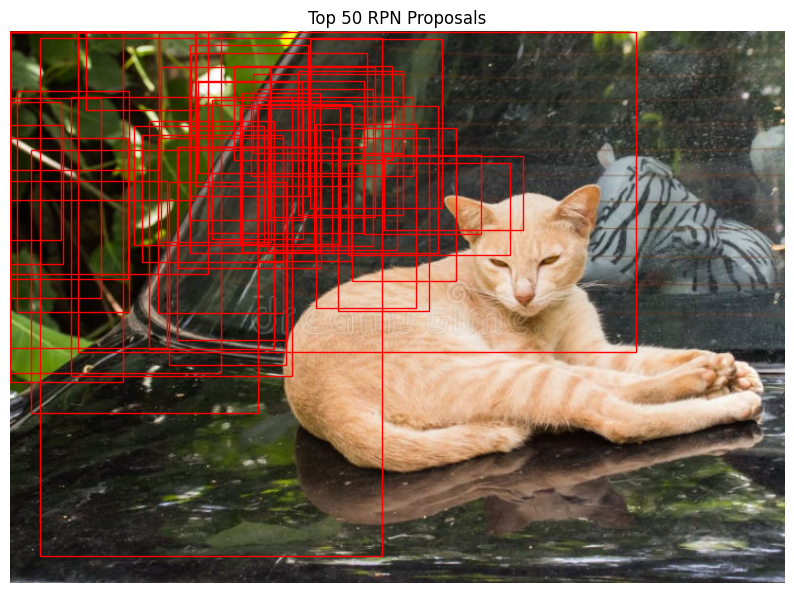

In [111]:
fig, ax = plt.subplots(1, figsize=(10,8))
ax.imshow(img_np)

for i in range(min(50, len(proposals))):  # draw top 50

    x1,y1,x2,y2 = proposals[i]

    rect = plt.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        fill=False,
        edgecolor='red',
        linewidth=1
    )

    ax.add_patch(rect)

plt.title("Top 50 RPN Proposals")
plt.axis("off")
plt.show()

### ROI Pooling

In [112]:
torchvision.ops.roi_pool

<function torchvision.ops.roi_pool.roi_pool(input: torch.Tensor, boxes: Union[torch.Tensor, list[torch.Tensor]], output_size: None, spatial_scale: float = 1.0) -> torch.Tensor>

In [113]:
proposals_tensor = torch.tensor(proposals, dtype=torch.float32)

batch_indices = torch.zeros((proposals_tensor.shape[0], 1))  # all from image 0

rois = torch.cat([batch_indices, proposals_tensor], dim=1).to(device)

print(rois.shape)

torch.Size([300, 5])


In [114]:
from torchvision.ops import roi_pool

In [115]:
pooled_features = roi_pool(
    feature_map,
    rois,
    output_size=(7,7),
    spatial_scale=1/16
)

In [116]:
print(pooled_features.shape)

torch.Size([300, 2048, 7, 7])


### Detection Head

In [117]:
class DetectionHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(in_channels * 7 * 7, 1024)
        self.fc2 = nn.Linear(1024, 1024)

        # classification
        self.cls_head = nn.Linear(1024, num_classes)

        # bbox regression
        self.reg_head = nn.Linear(1024, num_classes * 4)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        cls_logits = self.cls_head(x)
        bbox_reg = self.reg_head(x)

        return cls_logits, bbox_reg

In [118]:
num_classes = 21  # VOC style (20 + background)

In [119]:
det_head = DetectionHead(2048, num_classes).to(device)

In [120]:
with torch.no_grad():
    cls_logits, bbox_reg = det_head(pooled_features)

print("cls_logits:", cls_logits.shape)
print("bbox_reg:", bbox_reg.shape)

cls_logits: torch.Size([300, 21])
bbox_reg: torch.Size([300, 84])


In [121]:
probs = F.softmax(cls_logits, dim=1)

scores, labels = torch.max(probs, dim=1)

In [122]:
threshold = 0.06

keep = scores > threshold

final_boxes = proposals[keep.cpu().numpy()]
final_scores = scores[keep].cpu().numpy()
final_labels = labels[keep].cpu().numpy()

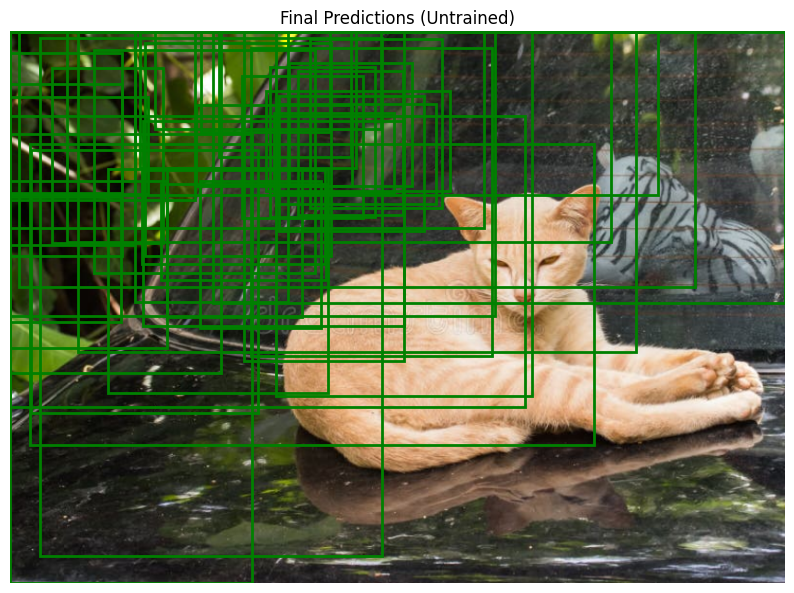

In [123]:
fig, ax = plt.subplots(1, figsize=(10,8))
ax.imshow(img_np)

for i in range(len(final_boxes)):

    x1,y1,x2,y2 = final_boxes[i]

    rect = plt.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        fill=False,
        edgecolor='green',
        linewidth=2
    )

    ax.add_patch(rect)

plt.title("Final Predictions (Untrained)")
plt.axis("off")
plt.show()

In [124]:
print(scores[:20])
print(scores.max())

tensor([0.0511, 0.0560, 0.0577, 0.0566, 0.0567, 0.0521, 0.0564, 0.0582, 0.0608,
        0.0566, 0.0577, 0.0600, 0.0561, 0.0534, 0.0550, 0.0523, 0.0576, 0.0546,
        0.0555, 0.0624], device='cuda:0')
tensor(0.0678, device='cuda:0')


## training

In [125]:
def compute_iou(boxes1, boxes2):

    N = boxes1.shape[0]
    M = boxes2.shape[0]

    ious = np.zeros((N, M))

    for i in range(N):
        x1,y1,x2,y2 = boxes1[i]

        for j in range(M):
            xx1,yy1,xx2,yy2 = boxes2[j]

            inter_x1 = max(x1, xx1)
            inter_y1 = max(y1, yy1)
            inter_x2 = min(x2, xx2)
            inter_y2 = min(y2, yy2)

            inter_w = max(0, inter_x2 - inter_x1)
            inter_h = max(0, inter_y2 - inter_y1)

            inter_area = inter_w * inter_h

            area1 = (x2-x1)*(y2-y1)
            area2 = (xx2-xx1)*(yy2-yy1)

            union = area1 + area2 - inter_area

            ious[i,j] = inter_area / (union + 1e-6)

    return ious

In [126]:
boxA = np.array([[50,50,150,150]])
boxB = np.array([[100,100,200,200]])

print(compute_iou(boxA, boxB))

[[0.14285714]]


In [127]:
gt_boxes = np.array([
    [300, 150, 800, 500]  # adjust if needed
])

In [128]:
def label_anchors(anchors, gt_boxes):

    ious = compute_iou(anchors, gt_boxes)

    max_iou = ious.max(axis=1)
    argmax_iou = ious.argmax(axis=1)

    labels = np.full(len(anchors), -1)  # -1 = ignore

    # positive
    labels[max_iou >= 0.7] = 1

    # negative
    labels[max_iou < 0.3] = 0

    # ensure at least one positive per GT
    gt_argmax = ious.argmax(axis=0)
    labels[gt_argmax] = 1

    return labels, argmax_iou

In [129]:
labels, matched_gt_idx = label_anchors(anchor_boxes, gt_boxes)

print("Positive:", np.sum(labels == 1))
print("Negative:", np.sum(labels == 0))
print("Ignored :", np.sum(labels == -1))

Positive: 1
Negative: 4513
Ignored : 103


In [130]:
def sample_anchors(labels, num_samples=256):

    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]

    num_pos = min(len(pos_idx), num_samples // 2)
    num_neg = num_samples - num_pos

    pos_sample = np.random.choice(pos_idx, num_pos, replace=False)
    neg_sample = np.random.choice(neg_idx, num_neg, replace=False)

    keep_idx = np.concatenate([pos_sample, neg_sample])

    return keep_idx

In [131]:
sample_idx = sample_anchors(labels)

print("Sampled anchors:", len(sample_idx))

Sampled anchors: 256


In [132]:
def compute_targets(anchors, gt_boxes, matched_idx):

    targets = []

    for i in range(len(anchors)):

        a = anchors[i]
        gt = gt_boxes[matched_idx[i]]

        ax1,ay1,ax2,ay2 = a
        gx1,gy1,gx2,gy2 = gt

        aw = ax2 - ax1
        ah = ay2 - ay1
        acx = ax1 + 0.5 * aw
        acy = ay1 + 0.5 * ah

        gw = gx2 - gx1
        gh = gy2 - gy1
        gcx = gx1 + 0.5 * gw
        gcy = gy1 + 0.5 * gh

        tx = (gcx - acx) / aw
        ty = (gcy - acy) / ah
        tw = np.log(gw / aw + 1e-6)
        th = np.log(gh / ah + 1e-6)

        targets.append([tx, ty, tw, th])

    return np.array(targets)

In [133]:
targets = compute_targets(anchor_boxes, gt_boxes, matched_gt_idx)

print(targets.shape)

(4617, 4)


### loss


In [134]:
labels_t = torch.tensor(labels).to(device)
targets_t = torch.tensor(targets, dtype=torch.float32).to(device)

sample_idx_t = torch.tensor(sample_idx).to(device)

In [135]:
labels_sampled = labels_t[sample_idx_t]
targets_sampled = targets_t[sample_idx_t]

cls_logits_sampled = cls_logits_rpn[sample_idx_t]
bbox_reg_sampled = bbox_reg_rpn[sample_idx_t]

In [136]:
valid_idx = labels_sampled != -1

cls_loss = F.cross_entropy(
    cls_logits_sampled[valid_idx],
    labels_sampled[valid_idx].long()
)

In [137]:
valid_idx = labels_sampled != -1

cls_loss = F.cross_entropy(
    cls_logits_sampled[valid_idx],
    labels_sampled[valid_idx].long()
)

In [138]:
pos_idx = labels_sampled == 1

In [139]:
if pos_idx.sum() > 0:
    reg_loss = F.smooth_l1_loss(
        bbox_reg_sampled[pos_idx],
        targets_sampled[pos_idx]
    )
else:
    reg_loss = torch.tensor(0.0).to(device)

In [140]:
lambda_reg = 10

loss = cls_loss + lambda_reg * reg_loss

print("Cls Loss:", cls_loss.item())
print("Reg Loss:", reg_loss.item())
print("Total Loss:", loss.item())

Cls Loss: 0.7045243382453918
Reg Loss: 0.018414443358778954
Total Loss: 0.8886687755584717


In [141]:
optimizer = torch.optim.Adam(rpn.parameters(), lr=1e-4)

In [143]:
for step in range(100):

    # 🔥 FORWARD (must be inside loop)
    cls_logits_rpn, bbox_reg_rpn = rpn(feature_map)

    cls_logits_rpn = cls_logits_rpn.permute(0,2,3,1).contiguous().view(-1,2)
    bbox_reg_rpn = bbox_reg_rpn.permute(0,2,3,1).contiguous().view(-1,4)

    # sample
    cls_logits_sampled = cls_logits_rpn[sample_idx_t]
    bbox_reg_sampled = bbox_reg_rpn[sample_idx_t]

    labels_sampled = labels_t[sample_idx_t]
    targets_sampled = targets_t[sample_idx_t]

    # loss
    valid_idx = labels_sampled != -1

    cls_loss = F.cross_entropy(
        cls_logits_sampled[valid_idx],
        labels_sampled[valid_idx].long()
    )

    pos_idx = labels_sampled == 1

    if pos_idx.sum() > 0:
        reg_loss = F.smooth_l1_loss(
            bbox_reg_sampled[pos_idx],
            targets_sampled[pos_idx]
        )
    else:
        reg_loss = torch.tensor(0.0).to(device)

    loss = cls_loss + 10 * reg_loss

    # 🔥 BACKWARD
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

Step 0, Loss: 1.2994
Step 10, Loss: 0.1060
Step 20, Loss: 0.0419
Step 30, Loss: 0.0151
Step 40, Loss: 0.0029
Step 50, Loss: 0.0031
Step 60, Loss: 0.0016
Step 70, Loss: 0.0014
Step 80, Loss: 0.0013
Step 90, Loss: 0.0009


In [144]:
cls_logits_rpn, bbox_reg_rpn = rpn(feature_map)

cls_logits_rpn = cls_logits_rpn.permute(0,2,3,1).contiguous().view(-1,2)
bbox_reg_rpn = bbox_reg_rpn.permute(0,2,3,1).contiguous().view(-1,4)

scores = F.softmax(cls_logits_rpn, dim=1)
object_scores = scores[:, 1]

In [145]:
bbox_reg_np = bbox_reg_rpn.detach().cpu().numpy()
proposals = decode_boxes(anchor_boxes, bbox_reg_np)

In [147]:
proposals = clip_boxes(proposals, (img_h, img_w))
keep = filter_small_boxes(proposals)

proposals = proposals[keep]
object_scores = object_scores[keep]

proposals_tensor = torch.tensor(proposals, dtype=torch.float32).to(device)
scores_tensor = object_scores.to(device)

keep_idx = nms(proposals_tensor, scores_tensor, iou_threshold=0.7)

proposals = proposals_tensor[keep_idx].cpu().numpy()

# 🔥 reduce for clarity
top_n = 50

scores_np = scores_tensor[keep_idx].cpu().detach().numpy()
order = scores_np.argsort()[::-1]

proposals = proposals[order[:top_n]]

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


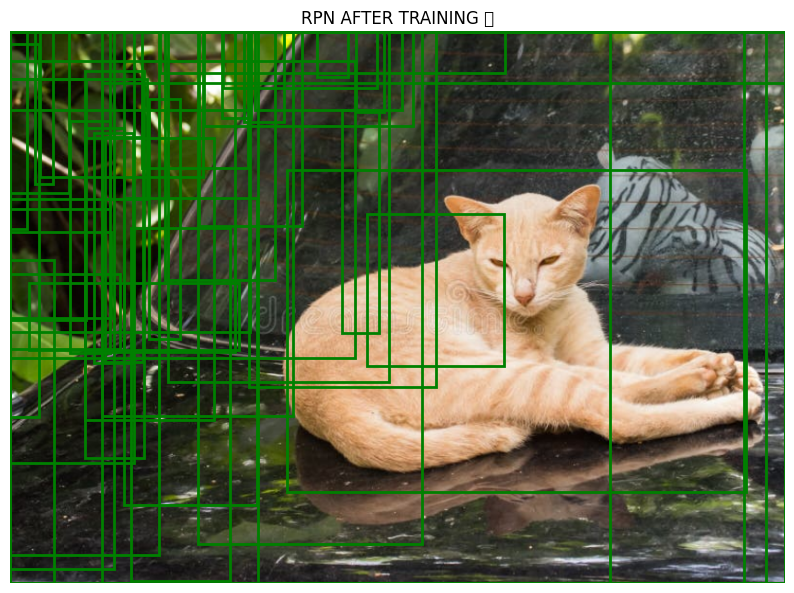

In [148]:
fig, ax = plt.subplots(1, figsize=(10,8))
ax.imshow(img_np)

for i in range(len(proposals)):

    x1,y1,x2,y2 = proposals[i]

    rect = plt.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        fill=False,
        edgecolor='green',
        linewidth=2
    )

    ax.add_patch(rect)

plt.title("RPN AFTER TRAINING 🔥")
plt.axis("off")
plt.show()

## detection head training

In [149]:
def label_proposals(proposals, gt_boxes):

    ious = compute_iou(proposals, gt_boxes)

    max_iou = ious.max(axis=1)
    argmax_iou = ious.argmax(axis=1)

    labels = np.zeros(len(proposals))  # default = background

    # positive
    labels[max_iou >= 0.5] = 1

    return labels, argmax_iou

In [150]:
proposal_labels, matched_gt_idx = label_proposals(proposals, gt_boxes)

print("Positive proposals:", np.sum(proposal_labels == 1))
print("Negative proposals:", np.sum(proposal_labels == 0))

Positive proposals: 2
Negative proposals: 48


In [152]:
proposal_targets = compute_targets(proposals, gt_boxes, matched_gt_idx)

In [153]:
proposal_labels_t = torch.tensor(proposal_labels).to(device)
proposal_targets_t = torch.tensor(proposal_targets, dtype=torch.float32).to(device)

In [154]:
cls_logits_det, bbox_reg_det = det_head(pooled_features)

In [157]:
proposals_tensor_for_det = torch.tensor(proposals, dtype=torch.float32)
batch_indices_for_det = torch.zeros((proposals_tensor_for_det.shape[0], 1))
rois_for_det = torch.cat([batch_indices_for_det, proposals_tensor_for_det], dim=1).to(device)

pooled_features_for_det = roi_pool(
    feature_map,
    rois_for_det,
    output_size=(7,7),
    spatial_scale=1/16
)

cls_logits_det, bbox_reg_det = det_head(pooled_features_for_det)

cls_loss_det = F.cross_entropy(
    cls_logits_det,
    proposal_labels_t.long()
)

In [158]:
pos_idx = proposal_labels_t == 1

if pos_idx.sum() > 0:
    reg_loss_det = F.smooth_l1_loss(
        bbox_reg_det[pos_idx, :4],   # class-agnostic for now
        proposal_targets_t[pos_idx]
    )
else:
    reg_loss_det = torch.tensor(0.0).to(device)

In [160]:
loss_det = cls_loss_det + reg_loss_det

print("Cls Loss:", cls_loss_det.item())
print("Reg Loss:", reg_loss_det.item())
print("Total Loss:", loss_det.item())

Cls Loss: 3.0428571701049805
Reg Loss: 0.026578079909086227
Total Loss: 3.0694353580474854


In [161]:
optimizer_det = torch.optim.Adam(det_head.parameters(), lr=1e-4)

In [162]:
optimizer_det.zero_grad()
loss_det.backward()
optimizer_det.step()

In [164]:
for step in range(100):

    # Use pooled_features_for_det which corresponds to the 50 proposals
    cls_logits_det, bbox_reg_det = det_head(pooled_features_for_det)

    cls_loss_det = F.cross_entropy(
        cls_logits_det,
        proposal_labels_t.long()
    )

    pos_idx = proposal_labels_t == 1

    if pos_idx.sum() > 0:
        reg_loss_det = F.smooth_l1_loss(
            bbox_reg_det[pos_idx, :4],
            proposal_targets_t[pos_idx]
        )
    else:
        reg_loss_det = torch.tensor(0.0).to(device)

    loss_det = cls_loss_det + reg_loss_det

    optimizer_det.zero_grad()
    loss_det.backward()
    optimizer_det.step()

    if step % 10 == 0:
        print(f"Step {step}, Loss: {loss_det.item():.4f}")

Step 0, Loss: 0.4444
Step 10, Loss: 0.1095
Step 20, Loss: 0.0628
Step 30, Loss: 0.0637
Step 40, Loss: 0.0622
Step 50, Loss: 0.0609
Step 60, Loss: 0.0604
Step 70, Loss: 0.0600
Step 80, Loss: 0.0597
Step 90, Loss: 0.0595


In [173]:
probs = F.softmax(cls_logits_det, dim=1)
scores, labels = torch.max(probs, dim=1)

threshold = 0.5
keep = scores > threshold

final_boxes = proposals[keep.cpu().numpy()]

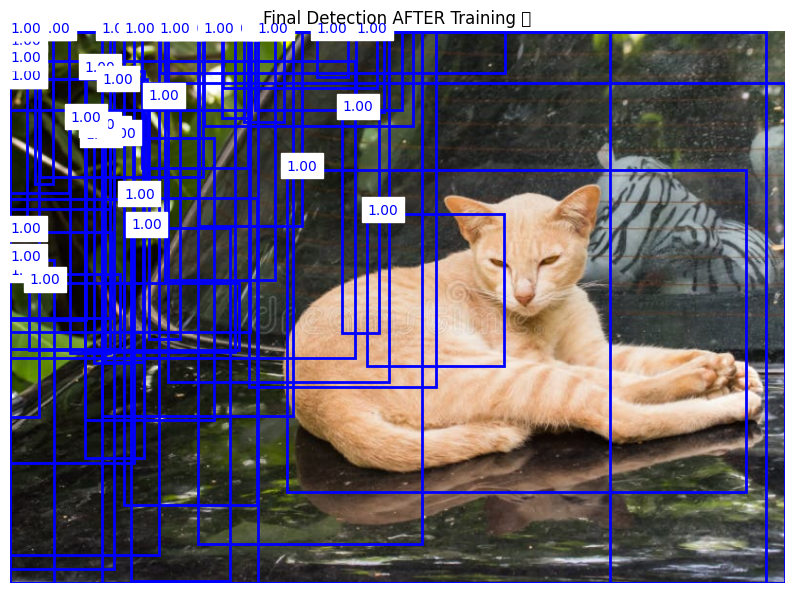

In [174]:
fig, ax = plt.subplots(1, figsize=(10,8))
ax.imshow(img_np)

for i in range(len(final_boxes)):

    x1, y1, x2, y2 = final_boxes[i]

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        edgecolor='blue',
        linewidth=2
    )

    ax.add_patch(rect)

    # optional: show score
    score = scores[keep][i].item()
    ax.text(
        x1, y1,
        f"{score:.2f}",
        color='blue',
        fontsize=10,
        backgroundcolor='white'
    )

plt.title("Final Detection AFTER Training 🔥")
plt.axis("off")
plt.show()